# K-Means Kümeleme ile Müşteri Segmentasyonu Analizi

In [ ]:
!pip install -q gdown
import gdown
gdown.download('https://drive.google.com/uc?id=1eamd5f2r6iVr1oq4oly79sGGD9iX73sy', 'musteri_segmentasyonu.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1eamd5f2r6iVr1oq4oly79sGGD9iX73sy
To: /content/musteri_segmentasyonu.csv
100%|██████████| 2.52k/2.52k [00:00<00:00, 8.62MB/s]


'musteri_segmentasyonu.csv'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('musteri_segmentasyonu.csv')

df.head()

,yillik_gelir,harcama_puani
0,16.8,88.3
1,45.6,40.3
2,44.7,49.1
3,87.7,92.7
4,34.1,81.0


In [ ]:
X = df[["yillik_gelir", "harcama_puani"]]

scaler = StandardScaler()
X_olcekli = scaler.fit_transform(X)

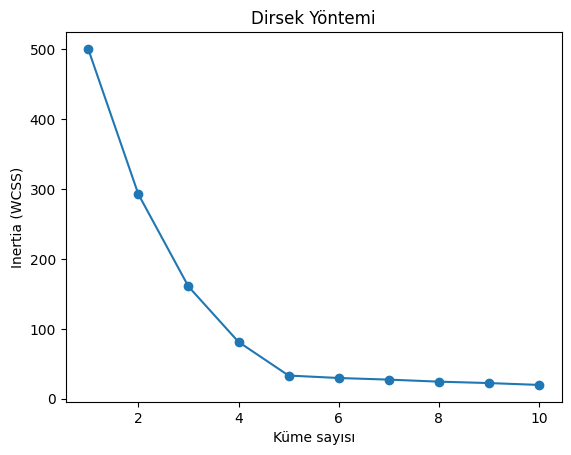

In [ ]:
k_degerleri = range(1, 11)
inertia_listesi = []

for k in k_degerleri:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(X_olcekli)
    inertia_listesi.append(kmeans.inertia_)

plt.plot(k_degerleri, inertia_listesi, marker = "o")
plt.xlabel("Küme sayısı")
plt.ylabel("Inertia (WCSS)")
plt.title("Dirsek Yöntemi")
plt.show()

In [ ]:
K = 5
kmeans_final = KMeans(n_clusters = K, random_state = 42, n_init = 10)
kumeler = kmeans_final.fit_predict(X_olcekli)

df["kume"] = kumeler
df.head()

,yillik_gelir,harcama_puani,kume
0,16.8,88.3,3
1,45.6,40.3,4
2,44.7,49.1,4
3,87.7,92.7,1
4,34.1,81.0,3


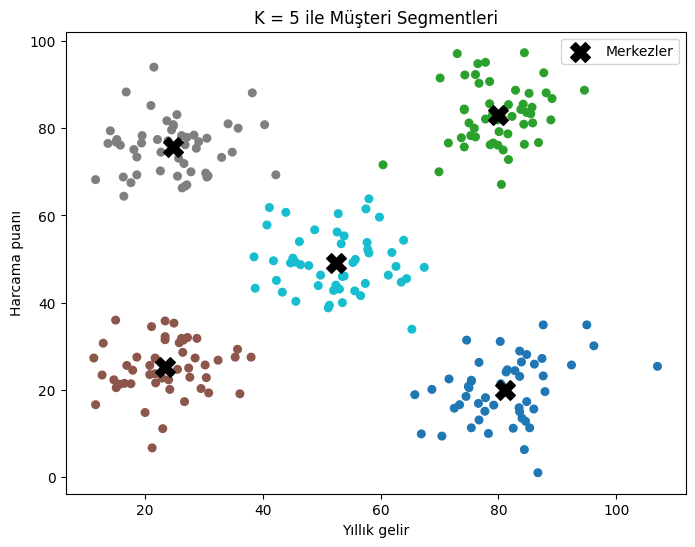

In [ ]:
merkezler_olcekli = kmeans_final.cluster_centers_
merkezler = scaler.inverse_transform(merkezler_olcekli)

plt.figure(figsize = (8,6))
plt.scatter(df["yillik_gelir"], df["harcama_puani"], c = df["kume"], cmap = "tab10", s = 30)
plt.scatter(merkezler[:,0], merkezler[:,1], c = "black", marker = "X", s = 200, label = "Merkezler")

plt.xlabel("Yıllık gelir")
plt.ylabel("Harcama puanı")
plt.title(f"K = {K} ile Müşteri Segmentleri")
plt.legend()
plt.show()

In [ ]:
skor = silhouette_score(X_olcekli, kumeler)
print("Silhouette skoru:", skor)

Silhouette skoru: 0.6800509512917465


In [ ]:
df.groupby("kume")[["yillik_gelir", "harcama_puani"]].mean()

,yillik_gelir,harcama_puani
kume,,
0,81.058000,19.916000
1,79.839216,83.045098
2,23.432000,25.126000
3,24.724000,75.592000
4,52.497959,49.112245


## Kümelerin Yorumlanması

Elde edilen 5 kümenin ortalama gelir ve harcama değerlerine bakıldığında her biri farklı bir müşteri segmentini temsil etmektedir.

- Küme 0 (Yıllık gelir = 81, Harcama puanı = 20): Yüksek gelir – düşük harcama grubu. Gelirine rağmen az harcayan, kampanyalarla mağazaya çekilebilecek müşterileri temsil eder.
- Küme 1 (Yıllık gelir = 80, Harcama puanı = 83): Yüksek gelir – yüksek harcama grubu. Mağaza için en değerli müşteri segmentidir.
- Küme 2 (Yıllık gelir = 23, Harcama puanı = 25): Düşük gelir – düşük harcama grubu. Hem geliri hem harcaması sınırlı, bütçesine dikkat eden müşterileri temsil eder.
- Küme 3 (Yıllık gelir = 25, Harcama puanı = 76): Düşük gelir – yüksek harcama grubu. Geliri düşük olmasına rağmen harcamaya istekli müşterileri temsil eder.
- Küme 4 (Yıllık gelir = 52, Harcama puanı = 49): Orta gelir – orta harcama grubu. Ortalama davranış sergileyen, dengeli müşteri kitlesidir.

Ayrıca K = 5 için hesaplanan silhouette skoru 0.68 olarak bulunmuştur. Bu değer 1'e yakın olduğu için kümelerin birbirinden iyi ayrıştığını, yani seçilen K değerinin (K = 5) veriye uygun olduğunu göstermektedir.